# 00_Low_HCRT_GWAS_PreQC

### Xinyu Li

### Last edit date: 8/6/2025

## Basic Ideas:
- Merge case & control data for 3 Axiom chips (EUR, AFR, EAS) and run Pre-QC script prior to downstream QC. 
Steps for each chip:
1. Extract case samples id from Excel file;
2. Use case samples id to extract corresponding genotype data from source files;
3. Extract controls from the GERA dataset;
4. Convert controls from hg18 -> hg19;
5. Use modified Pre-QC script to clean up case & control. 
6. Harmonize and merge controls & cases. 

- run Pre-QC script for PMRA by using provided script.

In [1]:
module load plink

## 1. Axiom_KP_UCSF_EUR

### Used Files:
- GWAS_lowHCRT_sample_list.xlsx
  
- Controls data:
/labs/mignot/raw_data/gwas/GERA_dbgap/phg000583.v2.GERA.genotype-calls-matrixfmt.Axiom_KP_UCSF_EUR.c1.HMB-IRB-NPU/Axiom_KP_UCSF_EUR_GERA

- Cases genotype data: /labs/mignot/raw_data/gwas/stanford/PLATES31_UP/raw/PLATES31_UP

- Script:
/labs/mignot/researchers/xinyuli/script/preQC.sh (modified from /labs/mignot/researchers/eyu8/scripts/non-gwas-chip_data_preStep1_clean_EY.sh)

/labs/mignot/researchers/xinyuli/script/harmonize_and_merge.sh

### 1.1 Extract EUR Case Genotypes

In [38]:
cd /labs/mignot/researchers/xinyuli/Axiom_KP_UCSF_EUR

In [60]:
head cases_ids.txt

Narcolepsy_33_B10_2233_B10_22.CEL	Narcolepsy_33_B10_2233_B10_22.CEL
Narcolepsy_33_B08_2033_B08_20.CEL	Narcolepsy_33_B08_2033_B08_20.CEL
Narcolepsy_33_B07_1933_B07_19.CEL	Narcolepsy_33_B07_1933_B07_19.CEL
Narcolepsy_33_B05_1733_B05_17.CEL	Narcolepsy_33_B05_1733_B05_17.CEL
Narcolepsy_34_E08_56.CEL	Narcolepsy_34_E08_56.CEL
Narcolepsy_34_D12_48.CEL	Narcolepsy_34_D12_48.CEL
Narcolepsy_34_D09_45.CEL	Narcolepsy_34_D09_45.CEL
Narcolepsy_37_G06_78.CEL	Narcolepsy_37_G06_78.CEL
Narcolepsy_37_G04_76.CEL	Narcolepsy_37_G04_76.CEL
Narcolepsy_37_G01_73.CEL	Narcolepsy_37_G01_73.CEL


In [61]:
plink \
--bfile /labs/mignot/raw_data/gwas/stanford/PLATES31_UP/raw/PLATES31_UP \
--keep cases_ids.txt \
--make-bed \
--out cases_EUR_final

PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to cases_EUR_final.log.
Options in effect:
  --bfile /labs/mignot/raw_data/gwas/stanford/PLATES31_UP/raw/PLATES31_UP
  --keep cases_ids.txt
  --make-bed
  --out cases_EUR_final

515883 MB RAM detected; reserving 257941 MB for main workspace.
665358 variants loaded from .bim file.
1727 people (0 males, 0 females, 1727 ambiguous) loaded from .fam.
Ambiguous sex IDs written to cases_EUR_final.nosex .
--keep: 274 people remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 274 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
treat these as missing.
Total genotyping rate in remaining

### 1.2 Extract EUR Control Genotypes

In [7]:
awk '{print $1, $2}' /labs/mignot/raw_data/gwas/GERA_dbgap/phg000583.v2.GERA.genotype-calls-matrixfmt.Axiom_KP_UCSF_EUR.c1.HMB-IRB-NPU/Axiom_KP_UCSF_EUR_GERA.fam > controls_EUR_ids.txt

In [8]:
 head controls_EUR_ids.txt

9908714 9908714
25424098 25424098
26339010 26339010
28209627 28209627
79345777 79345777
86847854 86847854
87733001 87733001
102245620 102245620
102625379 102625379
111130097 111130097


In [9]:
plink --bfile /labs/mignot/raw_data/gwas/GERA_dbgap/phg000583.v2.GERA.genotype-calls-matrixfmt.Axiom_KP_UCSF_EUR.c1.HMB-IRB-NPU/Axiom_KP_UCSF_EUR_GERA \
--keep controls_EUR_ids.txt \
--make-bed \
--out controls_EUR_only

PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to controls_EUR_only.log.
Options in effect:
  --bfile /labs/mignot/raw_data/gwas/GERA_dbgap/phg000583.v2.GERA.genotype-calls-matrixfmt.Axiom_KP_UCSF_EUR.c1.HMB-IRB-NPU/Axiom_KP_UCSF_EUR_GERA
  --keep controls_EUR_ids.txt
  --make-bed
  --out controls_EUR_only

515883 MB RAM detected; reserving 257941 MB for main workspace.
670176 variants loaded from .bim file.
62268 people (24924 males, 37307 females, 37 ambiguous) loaded from .fam.
Ambiguous sex IDs written to controls_EUR_only.nosex .
--keep: 62268 people remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 58785 founders and 3483 nonfounders present.
Calculating allele frequencies... 101112131415161718192021222324252627282930313233343536373839404142434445464748495051525354555657585960616263646566676869707172737475767778798081

- Since the location of SNPs in controls(hg18) didn't match with cases(hg19), we need to shift controls from hg18 to hg19 by using liftOver

- Create the input for liftOver
- Convert chr23 to chrX

In [10]:
awk '{chr_id = ($1 == 23) ? "X" : $1; print "chr"chr_id, $4-1, $4, $2}' controls_EUR_only.bim > controls_eur_for_liftover.bed

- Run liftOver

In [12]:
/labs/mignot/researchers/eyu8/soft/liftOver/liftOver \
controls_for_liftover.bed \
/labs/mignot/researchers/eyu8/soft/liftOver/hg18ToHg19.over.chain.gz \
controls_hg19_mapped.bed \
controls_hg19_unmapped.txt

Reading liftover chains
Mapping coordinates


 - Create clean files for PLINK update

In [13]:
awk '$3 > 0 {
    chr_val = $1;
    sub(/^chr/, "", chr_val);

    # if chr is X, modify it as 23
    if (chr_val == "X") {
        chr_val = 23;
    }

    print $4, chr_val, $3;

}' controls_hg19_mapped.bed > update_map_to_hg19.txt

In [14]:
awk '{sub(/^.:/, "", $4); print $4}' controls_hg19_unmapped.txt > snps_to_exclude.txt

 - Generate the final, corrected hg19 fileset

In [ ]:
plink \
--bfile controls_EUR_only \
--update-map update_map_to_hg19.txt \
--exclude snps_to_exclude.txt \
--make-bed \
--out controls_EUR_only_hg19

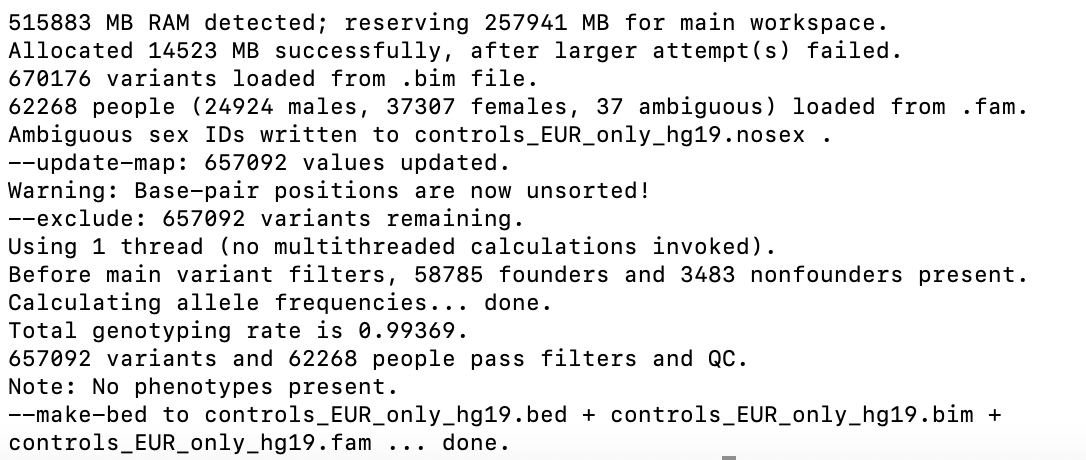

In [15]:
head controls_EUR_only_hg19.bim

1	b36:rs9701055	0	1	T	C
1	rs2073813	0	1	A	G
1	rs12184325	0	1	T	C
1	rs3131969	0	1	A	G
1	rs3131968	0	1	A	G
1	rs10454459	0	1	G	A
1	rs12562034	0	1	A	G
1	rs2518996	0	1	A	G
1	rs11579015	0	1	C	T
1	rs12134754	0	1	T	C


- There is an issue that the 1st and 4th columns in controls_EUR_only_hg19 are both chr, lack SNP positions. 
I fixed it by replacing the 4th column in controls_EUR_only_hg19.bim with the 3rd column in update_map_to_hg19.txt.

In [16]:
awk '
BEGIN { OFS="\t" }
NR==FNR { map[$1]=$3; next }
{
if ($2 in map) {
$4 = map[$2];
print $0
}
}
' update_map_to_hg19.txt controls_EUR_only_hg19.bim > final_corrected.bim

- Remove the "b36:" in the first row

In [17]:
awk 'BEGIN {OFS="\t"} {sub("b36:", "", $2); print $0}' final_corrected.bim > controls_EUR_only_hg19.clean.bim

In [18]:
mv controls_EUR_only_hg19.clean.bim controls_EUR_only_hg19.bim

In [19]:
head controls_EUR_only_hg19.bim

1	rs9701055	0	565433	T	C
1	rs2073813	0	753541	A	G
1	rs12184325	0	754105	T	C
1	rs3131969	0	754182	A	G
1	rs3131968	0	754192	A	G
1	rs10454459	0	754629	G	A
1	rs12562034	0	768448	A	G
1	rs2518996	0	792534	A	G
1	rs11579015	0	1036959	C	T
1	rs12134754	0	1037047	T	C


Now the information is correct.

### 1.3 Merge EUR Control and Case Datasets

- First, clean up controls & cases internally
- Script: /labs/mignot/researchers/xinyuli/script/preQC.sh

In [20]:
sh /labs/mignot/researchers/xinyuli/script/preQC.sh cases_EUR_final

--- Start Pre-QC for: cases_EUR_final ---
Step 1: Creating unique IDs and filtering...
PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to misscall_cases_EUR_final.log.
Options in effect:
  --bfile cases_EUR_final
  --bim cases_EUR_final_cp.bim
  --make-bed
  --out misscall_cases_EUR_final
  --snps-only just-acgt

515883 MB RAM detected; reserving 257941 MB for main workspace.
659990 out of 665358 variants loaded from .bim file.
274 people (0 males, 0 females, 274 ambiguous) loaded from .fam.
Ambiguous sex IDs written to misscall_cases_EUR_final.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 274 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091

In [22]:
head cases_EUR_final_uniq.bim

1	1:86028	0.0009	86028	C	T
1	1:564621	0.0062	564621	T	C
1	1:565400	0.0062	565400	T	C
1	1:565433	0.0062	565433	T	C
1	1:753541	0.0083	753541	A	G
1	1:754105	0.0083	754105	T	C
1	1:754182	0.0083	754182	A	G
1	1:754192	0.0083	754192	A	G
1	1:754629	0.0083	754629	G	A
1	1:768448	0.0085	768448	A	G


In [ ]:
sh /labs/mignot/researchers/xinyuli/script/preQC.sh controls_EUR_only_hg19

In [6]:
head controls_EUR_only_hg19_uniq.bim

1	1:565433	0	565433	T	C
1	1:753541	0	753541	A	G
1	1:754105	0	754105	T	C
1	1:754182	0	754182	A	G
1	1:754192	0	754192	A	G
1	1:754629	0	754629	G	A
1	1:768448	0	768448	A	G
1	1:792534	0	792534	A	G
1	1:1036959	0	1036959	C	T
1	1:1037047	0	1037047	T	C


- Second, Harmonize & Merge controls and cases
- Script: /labs/mignot/researchers/xinyuli/script/harmonize_and_merge.sh

In [ ]:
sh /labs/mignot/researchers/xinyuli/script/harmonize_and_merge.sh \
    cases_EUR_final_uniq \
    controls_EUR_only_hg19_uniq \
    EUR_merged_final

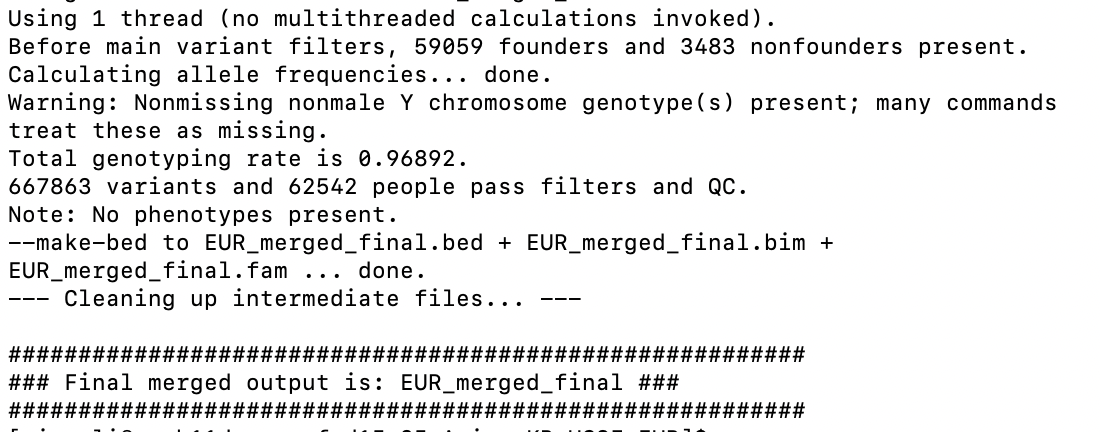

In [39]:
head EUR_merged_final.bim

1	1:86028	0.0009	86028	C	T
1	1:564621	0.0062	564621	T	C
1	1:565400	0.0062	565400	T	C
1	1:565433	0.0062	565433	T	C
1	1:753541	0.0083	753541	A	G
1	1:754105	0.0083	754105	T	C
1	1:754182	0.0083	754182	A	G
1	1:754192	0.0083	754192	A	G
1	1:754629	0.0083	754629	G	A
1	1:768448	0.0085	768448	A	G


In [25]:
grep "23:" EUR_merged_final.bim | head -n 5

23	23:2699968	0.0735	2699968	A	G
23	23:2700089	0.0735	2700089	G	A
23	23:2700157	0.0735	2700157	A	G
23	23:2700202	0.0735	2700202	G	A
23	23:2701185	0.0736	2701185	C	T


In [31]:
wc -l EUR_merged_final.bim

667863 EUR_merged_final.bim


### 1.4 Update Merged EUR Data for QC

- EUR sample_list file.

In [40]:
head sample_list.txt

Narcolepsy_33_B05_1733_B05_17.CEL Narcolepsy_33_B05_1733_B05_17.CEL 2
Narcolepsy_33_B07_1933_B07_19.CEL Narcolepsy_33_B07_1933_B07_19.CEL 2
Narcolepsy_33_B08_2033_B08_20.CEL Narcolepsy_33_B08_2033_B08_20.CEL 2
Narcolepsy_33_B10_2233_B10_22.CEL Narcolepsy_33_B10_2233_B10_22.CEL 2
Narcolepsy_34_D09_45.CEL Narcolepsy_34_D09_45.CEL 2
Narcolepsy_34_D12_48.CEL Narcolepsy_34_D12_48.CEL 2
Narcolepsy_34_E08_56.CEL Narcolepsy_34_E08_56.CEL 2
Narcolepsy_37_A05_5.CEL Narcolepsy_37_A05_5.CEL 2
Narcolepsy_37_A06_6.CEL Narcolepsy_37_A06_6.CEL 2
Narcolepsy_37_C12_36.CEL Narcolepsy_37_C12_36.CEL 2


- EUR sex.txt file

In [26]:
awk '{print $1, $2, $5}' controls_EUR_only_hg19_uniq.fam >> sex.txt

In [27]:
head sex.txt

Narcolepsy_33_B10_2233_B10_22.CEL	Narcolepsy_33_B10_2233_B10_22.CEL	1
Narcolepsy_33_B08_2033_B08_20.CEL	Narcolepsy_33_B08_2033_B08_20.CEL	2
Narcolepsy_33_B07_1933_B07_19.CEL	Narcolepsy_33_B07_1933_B07_19.CEL	2
Narcolepsy_33_B05_1733_B05_17.CEL	Narcolepsy_33_B05_1733_B05_17.CEL	1
Narcolepsy_34_E08_56.CEL	Narcolepsy_34_E08_56.CEL	2
Narcolepsy_34_D12_48.CEL	Narcolepsy_34_D12_48.CEL	2
Narcolepsy_34_D09_45.CEL	Narcolepsy_34_D09_45.CEL	1
Narcolepsy_37_G06_78.CEL	Narcolepsy_37_G06_78.CEL	1
Narcolepsy_37_G04_76.CEL	Narcolepsy_37_G04_76.CEL	2
Narcolepsy_37_G01_73.CEL	Narcolepsy_37_G01_73.CEL	1


In [47]:
plink \
    --bfile EUR_merged_final \
    --pheno sample_list.txt \
    --make-bed \
    --out EUR_merged_final_annotated \
    --update-sex sex.txt

PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to EUR_merged_final_annotated.log.
Options in effect:
  --bfile EUR_merged_final
  --make-bed
  --out EUR_merged_final_annotated
  --pheno sample_list.txt
  --update-sex sex.txt

515883 MB RAM detected; reserving 257941 MB for main workspace.
667863 variants loaded from .bim file.
62542 people (24924 males, 37307 females, 311 ambiguous) loaded from .fam.
Ambiguous sex IDs written to EUR_merged_final_annotated.nosex .
62542 phenotype values present after --pheno.
--update-sex: 62542 people updated.
phenotypes to be ignored, use the --allow-no-sex flag.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 59059 founders and 3483 nonfounders present.
Calculating allele frequencies... 1011121314151617181920212223242526272829303132333435363738394041424344454647484950515253545556575859606162636465

In [48]:
head EUR_merged_final_annotated.bim

1	1:86028	0.0009	86028	C	T
1	1:564621	0.0062	564621	T	C
1	1:565400	0.0062	565400	T	C
1	1:565433	0.0062	565433	T	C
1	1:753541	0.0083	753541	A	G
1	1:754105	0.0083	754105	T	C
1	1:754182	0.0083	754182	A	G
1	1:754192	0.0083	754192	A	G
1	1:754629	0.0083	754629	G	A
1	1:768448	0.0085	768448	A	G


In [9]:
grep "23:" EUR_merged_final_annotated.bim | head -n 5

23	23:2699968	0.0735	2699968	A	G
23	23:2700089	0.0735	2700089	G	A
23	23:2700157	0.0735	2700157	A	G
23	23:2700202	0.0735	2700202	G	A
23	23:2701185	0.0736	2701185	C	T


In [12]:
wc -l EUR_merged_final.fam

62542 EUR_merged_final.fam


In [6]:
awk '$6 == 2' EUR_merged_final_annotated.fam | wc -l

274


In [7]:
awk '$6 == 1' EUR_merged_final_annotated.fam | wc -l

62268


In [39]:
awk '{ count[$5]++ } END { for (sex in count) print "Sex Code", sex, ":", count[sex], "samples" }' EUR_merged_final_annotated.fam

Sex Code 0 : 40 samples
Sex Code 1 : 25054 samples
Sex Code 2 : 37448 samples


## 2. Axiom_KP_UCSF_AFR

### Used Files:
- GWAS_lowHCRT_sample_list.xlsx
  
- Controls data:
/labs/mignot/raw_data/gwas/GERA_dbgap/phg000583.v2.GERA.genotype-calls-matrixfmt.Axiom_KP_UCSF_AFR.c1.HMB-IRB-NPU/Axiom_KP_UCSF_AFR_GERA

- Cases genotype data:
/labs/mignot/raw_data/gwas/stanford/Axiom_KP_UCSF_AFR_35_36_55/raw/Axiom_KP_UCSF_AFR_PLATES_35_36
/labs/mignot/raw_data/gwas/stanford/Axiom_KP_UCSF_AFR_35_36_55/raw/Axiom_KP_UCSF_AFR_PLATES_55

- Script:
/labs/mignot/researchers/xinyuli/script/preQC.sh

/labs/mignot/researchers/xinyuli/script/harmonize_and_merge.sh

### 2.1 Extract AFR Case Genotypes

In [36]:
cd /labs/mignot/researchers/xinyuli/Axiom_KP_UCSF_AFR

- Axiom_KP_UCSF_AFR_PLATES_35_36

Filtered "Chip = Axiom_KP_UCSF_AFR", "Plate = 35 and 36" in GWAS_lowHCRT_sample_list.xlsx, copied "FID" and "IID" into cases_35_36_ids.txt

In [8]:
head cases_35_36_ids.txt

Narcolepsy_35_H08_92.CEL	Narcolepsy_35_H08_92.CEL
Narcolepsy_35_H06_90.CEL	Narcolepsy_35_H06_90.CEL
Narcolepsy_35_H05_89.CEL	Narcolepsy_35_H05_89.CEL
Narcolepsy_35_H04_88.CEL	Narcolepsy_35_H04_88.CEL
Narcolepsy_35_H02_86.CEL	Narcolepsy_35_H02_86.CEL
Narcolepsy_35_G12_84.CEL	Narcolepsy_35_G12_84.CEL
Narcolepsy_35_G11_83.CEL	Narcolepsy_35_G11_83.CEL
Narcolepsy_35_G10_82.CEL	Narcolepsy_35_G10_82.CEL
Narcolepsy_35_G07_79.CEL	Narcolepsy_35_G07_79.CEL
Narcolepsy_35_G06_78.CEL	Narcolepsy_35_G06_78.CEL


In [9]:
plink --bfile /labs/mignot/raw_data/gwas/stanford/Axiom_KP_UCSF_AFR_35_36_55/raw/Axiom_KP_UCSF_AFR_PLATES_35_36 \
--keep cases_35_36_ids.txt \
--make-bed \
--out cases_35_36_extracted

PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to cases_35_36_extracted.log.
Options in effect:
  --bfile /labs/mignot/raw_data/gwas/stanford/Axiom_KP_UCSF_AFR_35_36_55/raw/Axiom_KP_UCSF_AFR_PLATES_35_36
  --keep cases_35_36_ids.txt
  --make-bed
  --out cases_35_36_extracted

515883 MB RAM detected; reserving 257941 MB for main workspace.
794371 variants loaded from .bim file.
172 people (0 males, 0 females, 172 ambiguous) loaded from .fam.
Ambiguous sex IDs written to cases_35_36_extracted.nosex .
--keep: 30 people remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 30 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
trea

In [31]:
wc -l cases_35_36_extracted.fam

30 cases_35_36_extracted.fam


In [32]:
wc -l cases_35_36_extracted.bim

794371 cases_35_36_extracted.bim


- Axiom_KP_UCSF_AFR_PLATES_55

Filtered "Chip = Axiom_KP_UCSF_AFR", "Plate = 55" in GWAS_lowHCRT_sample_list.xlsx, copied "FID" and "IID" into cases_55_ids.txt

In [10]:
head cases_55_ids.txt

narcolepsy_55_H12_96.CEL	narcolepsy_55_H12_96.CEL
narcolepsy_55_H11_95.CEL	narcolepsy_55_H11_95.CEL
narcolepsy_55_H09_93.CEL	narcolepsy_55_H09_93.CEL
narcolepsy_55_H08_92.CEL	narcolepsy_55_H08_92.CEL
narcolepsy_55_H07_91.CEL	narcolepsy_55_H07_91.CEL
narcolepsy_55_H05_89.CEL	narcolepsy_55_H05_89.CEL
narcolepsy_55_H04_88.CEL	narcolepsy_55_H04_88.CEL
narcolepsy_55_H02_86.CEL	narcolepsy_55_H02_86.CEL
narcolepsy_55_H01_85.CEL	narcolepsy_55_H01_85.CEL
narcolepsy_55_G12_84.CEL	narcolepsy_55_G12_84.CEL


In [11]:
plink --bfile /labs/mignot/raw_data/gwas/stanford/Axiom_KP_UCSF_AFR_35_36_55/raw/Axiom_KP_UCSF_AFR_PLATES_55 \
--keep cases_55_ids.txt \
--make-bed \
--out cases_55_extracted

PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to cases_55_extracted.log.
Options in effect:
  --bfile /labs/mignot/raw_data/gwas/stanford/Axiom_KP_UCSF_AFR_35_36_55/raw/Axiom_KP_UCSF_AFR_PLATES_55
  --keep cases_55_ids.txt
  --make-bed
  --out cases_55_extracted

515883 MB RAM detected; reserving 257941 MB for main workspace.
820506 variants loaded from .bim file.
93 people (0 males, 0 females, 93 ambiguous) loaded from .fam.
Ambiguous sex IDs written to cases_55_extracted.nosex .
--keep: 39 people remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 39 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
treat these as missin

In [30]:
wc -l cases_55_extracted.fam

39 cases_55_extracted.fam


In [33]:
wc -l cases_55_extracted.bim

820506 cases_55_extracted.bim


- Merge plate 35_36 & plate 55
- Add --geno 0.05 command.

In [55]:
plink --bfile cases_35_36_extracted \
--bmerge cases_55_extracted.bed cases_55_extracted.bim cases_55_extracted.fam \
--make-bed \
--geno 0.05 \
--out cases_AFR_final

PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to cases_AFR_final.log.
Options in effect:
  --bfile cases_35_36_extracted
  --bmerge cases_55_extracted.bed cases_55_extracted.bim cases_55_extracted.fam
  --geno 0.05
  --make-bed
  --out cases_AFR_final

515883 MB RAM detected; reserving 257941 MB for main workspace.
30 people loaded from cases_35_36_extracted.fam.
39 people to be merged from cases_55_extracted.fam.
Of these, 39 are new, while 0 are present in the base dataset.
794371 markers loaded from cases_35_36_extracted.bim.
820506 markers to be merged from cases_55_extracted.bim.
Of these, 60503 are new, while 760003 are present in the base dataset.
Performing single-pass merge (69 people, 854874 variants).
Merged fileset written to cases_AFR_final-merge.bed + cases_AFR_final-merge.bim
+ cases_AFR_final-merge.fam .
854874 variants loaded from .bim file.
69 people

In [29]:
wc -l cases_AFR_final.fam

69 cases_AFR_final.fam


In [34]:
wc -l cases_AFR_final.bim

758973 cases_AFR_final.bim


### 2.2 Extract AFR Control Genotypes

In [14]:
awk '{print $1, $2}' /labs/mignot/raw_data/gwas/GERA_dbgap/phg000583.v2.GERA.genotype-calls-matrixfmt.Axiom_KP_UCSF_AFR.c1.HMB-IRB-NPU/Axiom_KP_UCSF_AFR_GERA.fam > controls_AFR_ids.txt

In [15]:
head controls_AFR_ids.txt

200947782 200947782
482847434 482847434
671617441 671617441
887207193 887207193
1017194578 1017194578
1403325962 1403325962
1497363846 1497363846
1912397802 1912397802
2150156618 2150156618
2304512279 2304512279


In [13]:
plink \
--bfile /labs/mignot/raw_data/gwas/GERA_dbgap/phg000583.v2.GERA.genotype-calls-matrixfmt.Axiom_KP_UCSF_AFR.c1.HMB-IRB-NPU/Axiom_KP_UCSF_AFR_GERA \
--keep controls_AFR_ids.txt \
--make-bed \
--out controls_AFR_only

PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to controls_AFR_only.log.
Options in effect:
  --bfile /labs/mignot/raw_data/gwas/GERA_dbgap/phg000583.v2.GERA.genotype-calls-matrixfmt.Axiom_KP_UCSF_AFR.c1.HMB-IRB-NPU/Axiom_KP_UCSF_AFR_GERA
  --keep controls_AFR_ids.txt
  --make-bed
  --out controls_AFR_only

515883 MB RAM detected; reserving 257941 MB for main workspace.
877845 variants loaded from .bim file.
3822 people (2406 males, 1411 females, 5 ambiguous) loaded from .fam.
Ambiguous sex IDs written to controls_AFR_only.nosex .
--keep: 3822 people remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 3653 founders and 169 nonfounders present.
Calculating allele frequencies... 1011121314151617181920212223242526272829303132333435363738394041424344454647484950515253545556575859606162636465666768697071727374757677787980818283848

- Again, run liftOver to transform controls from hg18 to hg19.
- Convert chr23 to chrX

In [18]:
awk '{chr_id = ($1 == 23) ? "X" : $1; print "chr"chr_id, $4-1, $4, $2}' controls_AFR_only.bim > controls_afr_for_liftover.bed

In [21]:
grep "chrX" controls_afr_for_liftover.bed | head -n 5

chrX 2709967 2709968 rs2306737
chrX 2710201 2710202 rs5939320
chrX 2711184 2711185 rs1970797
chrX 2711360 2711361 rs35378569
chrX 2713632 2713633 rs1419931


In [19]:
/labs/mignot/researchers/eyu8/soft/liftOver/liftOver \
controls_afr_for_liftover.bed \
/labs/mignot/researchers/eyu8/soft/liftOver/hg18ToHg19.over.chain.gz \
controls_afr_hg19_mapped.bed \
controls_afr_hg19_unmapped.txt

Reading liftover chains
Mapping coordinates


In [26]:
awk '$3 > 0 {
    chr_val = $1;
    sub(/^chr/, "", chr_val);

    # if chr is X, modify it as 23
    if (chr_val == "X") {
        chr_val = 23;
    }

    print $4, chr_val, $3;

}' controls_afr_hg19_mapped.bed > update_map_to_hg19.txt

In [27]:
awk '{sub(/^.:/, "", $4); print $4}' controls_afr_hg19_unmapped.txt > snps_to_exclude.txt

In [28]:
plink \
--bfile controls_AFR_only \
--update-map update_map_to_hg19.txt \
--exclude snps_to_exclude.txt \
--make-bed \
--out controls_AFR_only_hg19

PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to controls_AFR_only_hg19.log.
Options in effect:
  --bfile controls_AFR_only
  --exclude snps_to_exclude.txt
  --make-bed
  --out controls_AFR_only_hg19
  --update-map update_map_to_hg19.txt

515883 MB RAM detected; reserving 257941 MB for main workspace.
877845 variants loaded from .bim file.
3822 people (2406 males, 1411 females, 5 ambiguous) loaded from .fam.
Ambiguous sex IDs written to controls_AFR_only_hg19.nosex .
--update-map: 876519 values updated.
--exclude: 876519 variants remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 3653 founders and 169 nonfounders present.
Calculating allele frequencies... 101112131415161718192021222324252627282930313233343536373839404142434445464748495051525354555657585960616263646566676869707172737475767778798081828384858687888990919293949

In [29]:
head controls_AFR_only_hg19.bim

1	b36:rs9699599	0	1	G	A
1	rs12184325	0	1	T	C
1	rs3131969	0	1	A	G
1	rs4951929	0	1	C	T
1	rs12562034	0	1	A	G
1	rs2977613	0	1	G	T
1	rs2980300	0	1	T	C
1	rs115290438	0	1	C	T
1	rs74045281	0	1	A	G
1	rs2518996	0	1	A	G


- Need to fix the 4th column again.

In [30]:
awk '
BEGIN { OFS="\t" }
NR==FNR { map[$1]=$3; next }
{
if ($2 in map) {
$4 = map[$2];
print $0
}
}
' update_map_to_hg19.txt controls_AFR_only_hg19.bim > final_corrected.bim

In [31]:
awk 'BEGIN {OFS="\t"} {sub("b36:", "", $2); print $0}'  final_corrected.bim > controls_AFR_only_hg19.clean.bim

In [32]:
mv controls_AFR_only_hg19.clean.bim controls_AFR_only_hg19.bim

In [33]:
head controls_AFR_only_hg19.bim

1	rs9699599	0	568322	G	A
1	rs12184325	0	754105	T	C
1	rs3131969	0	754182	A	G
1	rs4951929	0	757734	C	T
1	rs12562034	0	768448	A	G
1	rs2977613	0	780027	G	T
1	rs2980300	0	785989	T	C
1	rs115290438	0	788004	C	T
1	rs74045281	0	790188	A	G
1	rs2518996	0	792534	A	G


In [26]:
wc -l controls_AFR_only_hg19.fam

3822 controls_AFR_only_hg19.fam


In [11]:
wc -l controls_AFR_only_hg19.bim

876519 controls_AFR_only_hg19.bim


### 2.3 Merge AFR Control and Case Datasets

- First, clean up controls & cases internally
- Script: /labs/mignot/researchers/xinyuli/script/preQC.sh(modified from non-gwas-chip_data_preStep1_clean_EY.sh)

In [35]:
sh /labs/mignot/researchers/xinyuli/script/preQC.sh cases_AFR_final

--- Start Pre-QC for: cases_AFR_final ---
Step 1: Creating unique IDs and filtering...
PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to misscall_cases_AFR_final.log.
Options in effect:
  --bfile cases_AFR_final
  --bim cases_AFR_final_cp.bim
  --make-bed
  --out misscall_cases_AFR_final
  --snps-only just-acgt

515883 MB RAM detected; reserving 257941 MB for main workspace.
755639 out of 758973 variants loaded from .bim file.
69 people (0 males, 0 females, 69 ambiguous) loaded from .fam.
Ambiguous sex IDs written to misscall_cases_AFR_final.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 69 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929

In [36]:
head cases_AFR_final_uniq.bim

1	1:754105	0	754105	T	C
1	1:754182	0	754182	G	A
1	1:757734	0	757734	T	C
1	1:768448	0	768448	A	G
1	1:780027	0	780027	G	T
1	1:785989	0	785989	C	T
1	1:788004	0	788004	C	T
1	1:790188	0	790188	A	G
1	1:794374	0	794374	C	T
1	1:799463	0	799463	T	C


In [14]:
wc -l cases_AFR_final_uniq.bim

755639 cases_AFR_final_uniq.bim


In [37]:
sh /labs/mignot/researchers/xinyuli/script/preQC.sh controls_AFR_only_hg19

--- Start Pre-QC for: controls_AFR_only_hg19 ---
Step 1: Creating unique IDs and filtering...
PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to misscall_controls_AFR_only_hg19.log.
Options in effect:
  --bfile controls_AFR_only_hg19
  --bim controls_AFR_only_hg19_cp.bim
  --make-bed
  --out misscall_controls_AFR_only_hg19
  --snps-only just-acgt

515883 MB RAM detected; reserving 257941 MB for main workspace.
872254 out of 876519 variants loaded from .bim file.
3822 people (2406 males, 1411 females, 5 ambiguous) loaded from .fam.
Ambiguous sex IDs written to misscall_controls_AFR_only_hg19.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 3653 founders and 169 nonfounders present.
Calculating allele frequencies... 101112131415161718192021222324252627282930313233343536373839404142434445464748495051525354555657585960616263646566

In [38]:
head controls_AFR_only_hg19_uniq.bim

1	1:568322	0	568322	G	A
1	1:754105	0	754105	T	C
1	1:754182	0	754182	A	G
1	1:757734	0	757734	C	T
1	1:768448	0	768448	A	G
1	1:780027	0	780027	G	T
1	1:785989	0	785989	T	C
1	1:788004	0	788004	C	T
1	1:790188	0	790188	A	G
1	1:792534	0	792534	A	G


In [27]:
wc -l controls_AFR_only_hg19_uniq.fam

3822 controls_AFR_only_hg19_uniq.fam


In [13]:
wc -l controls_AFR_only_hg19_uniq.bim

872254 controls_AFR_only_hg19_uniq.bim


- Second, Harmonize & Merge controls and cases
- Script: /labs/mignot/researchers/xinyuli/script/harmonize_and_merge.sh
- Extract the common SNPs in cases & controls first, then merge them, in order to prevent all cases being filtered in the qc step.

In [7]:
awk '{print $2}' cases_AFR_final_uniq.bim > case_snps.txt

In [10]:
head -n 5 case_snps.txt

1:754105
1:754182
1:757734
1:768448
1:780027


In [9]:
awk '{print $2}' controls_AFR_only_hg19_uniq.bim > control_snps.txt

In [11]:
head -n 5 control_snps.txt

1:568322
1:754105
1:754182
1:757734
1:768448


In [12]:
grep -xF -f case_snps.txt control_snps.txt > common_snps.txt

In [13]:
wc -l common_snps.txt

748130 common_snps.txt


In [15]:
plink --bfile cases_AFR_final_uniq \
    --extract common_snps.txt \
    --make-bed \
    --out cases_AFR_common

PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to cases_AFR_common.log.
Options in effect:
  --bfile cases_AFR_final_uniq
  --extract common_snps.txt
  --make-bed
  --out cases_AFR_common

515883 MB RAM detected; reserving 257941 MB for main workspace.
755639 variants loaded from .bim file.
69 people (0 males, 0 females, 69 ambiguous) loaded from .fam.
Ambiguous sex IDs written to cases_AFR_common.nosex .
--extract: 748130 variants remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 69 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is 0.997025.
748130 variants and 69 people pass filters and QC.
Note

In [16]:
plink --bfile controls_AFR_only_hg19_uniq \
    --extract common_snps.txt \
    --make-bed \
    --out controls_AFR_common

PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to controls_AFR_common.log.
Options in effect:
  --bfile controls_AFR_only_hg19_uniq
  --extract common_snps.txt
  --make-bed
  --out controls_AFR_common

515883 MB RAM detected; reserving 257941 MB for main workspace.
872254 variants loaded from .bim file.
3822 people (2406 males, 1411 females, 5 ambiguous) loaded from .fam.
Ambiguous sex IDs written to controls_AFR_common.nosex .
--extract: 748130 variants remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 3653 founders and 169 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
many commands treat these as missing.
Total genotyping rate is 

In [17]:
sh /labs/mignot/researchers/xinyuli/script/harmonize_and_merge.sh \
    cases_AFR_common \
    controls_AFR_common \
    AFR_merged_final

### STARTING FINAL HARMONIZE & MERGE PIPELINE ###
### Case Input: cases_AFR_common ###
### Control Input: controls_AFR_common ###
### Final Output: AFR_merged_final ###
--- Stage 1: Harmonizing Case alleles to Control reference... ---
PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to cases_AFR_common_harmonized.log.
Options in effect:
  --a1-allele ref_alleles.txt
  --bfile cases_AFR_common
  --make-bed
  --out cases_AFR_common_harmonized

515883 MB RAM detected; reserving 257941 MB for main workspace.
748130 variants loaded from .bim file.
69 people (0 males, 0 females, 69 ambiguous) loaded from .fam.
Ambiguous sex IDs written to cases_AFR_common_harmonized.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 69 founders and 0 nonfounders present.
Calculating allele frequencies... 101112131415161718192021222324252627282930313233

In [18]:
head AFR_merged_final.bim

1	1:754105	0	754105	T	C
1	1:754182	0	754182	A	G
1	1:757734	0	757734	C	T
1	1:768448	0	768448	A	G
1	1:780027	0	780027	G	T
1	1:785989	0	785989	T	C
1	1:788004	0	788004	C	T
1	1:790188	0	790188	A	G
1	1:794374	0	794374	C	T
1	1:799463	0	799463	T	C


In [28]:
wc -l AFR_merged_final.bim

729978 AFR_merged_final.bim


In [19]:
wc -l AFR_merged_final.fam

3891 AFR_merged_final.fam


In [9]:
awk '$6 == 2' AFR_merged_final_annotated.fam | wc -l

69


In [10]:
awk '$6 == 1' AFR_merged_final_annotated.fam | wc -l

3822


### 2.4 Update Merged AFR Data for QC

- Check the AFR sample_list (phenotype) file.

In [41]:
head sample_list.txt

Narcolepsy_35_B01_13.CEL Narcolepsy_35_B01_13.CEL 2
Narcolepsy_35_E11_59.CEL Narcolepsy_35_E11_59.CEL 2
Narcolepsy_35_F06_66.CEL Narcolepsy_35_F06_66.CEL 2
Narcolepsy_35_F07_67.CEL Narcolepsy_35_F07_67.CEL 2
Narcolepsy_35_F08_68.CEL Narcolepsy_35_F08_68.CEL 2
Narcolepsy_35_F09_69.CEL Narcolepsy_35_F09_69.CEL 2
Narcolepsy_35_G06_78.CEL Narcolepsy_35_G06_78.CEL 2
Narcolepsy_35_G07_79.CEL Narcolepsy_35_G07_79.CEL 2
Narcolepsy_35_G10_82.CEL Narcolepsy_35_G10_82.CEL 2
Narcolepsy_35_G11_83.CEL Narcolepsy_35_G11_83.CEL 2


- Check AFR sex.txt

In [48]:
awk '{print $1, $2, $5}' controls_AFR_only_hg19_uniq.fam >> sex.txt

In [49]:
sort -u sex.txt > sex_unique.txt

In [50]:
mv sex_unique.txt sex.txt

In [3]:
head sex.txt

100004401670 100004401670 2
1000237667585 1000237667585 1
1000392956124 1000392956124 2
1000441787779 1000441787779 1
1000719708014 1000719708014 2
1000970049755 1000970049755 2
1001063707408 1001063707408 1
1001843461854 1001843461854 1
1002011628001 1002011628001 1
1002233612770 1002233612770 2


In [21]:
plink \
    --bfile AFR_merged_final \
    --pheno sample_list.txt \
    --make-bed \
    --out AFR_merged_final_annotated \
    --update-sex sex.txt

PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to AFR_merged_final_annotated.log.
Options in effect:
  --bfile AFR_merged_final
  --make-bed
  --out AFR_merged_final_annotated
  --pheno sample_list.txt
  --update-sex sex.txt

515883 MB RAM detected; reserving 257941 MB for main workspace.
729978 variants loaded from .bim file.
3891 people (2406 males, 1411 females, 74 ambiguous) loaded from .fam.
Ambiguous sex IDs written to AFR_merged_final_annotated.nosex .
3891 phenotype values present after --pheno.
--update-sex: 3891 people updated, 2 IDs not present.
phenotypes to be ignored, use the --allow-no-sex flag.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 3722 founders and 169 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596

In [22]:
head AFR_merged_final_annotated.bim

1	1:754105	0	754105	T	C
1	1:754182	0	754182	A	G
1	1:757734	0	757734	C	T
1	1:768448	0	768448	A	G
1	1:780027	0	780027	G	T
1	1:785989	0	785989	T	C
1	1:788004	0	788004	C	T
1	1:790188	0	790188	A	G
1	1:794374	0	794374	C	T
1	1:799463	0	799463	T	C


In [23]:
grep "23:" AFR_merged_final_annotated.bim | head -n 5

23	23:2699968	0	2699968	A	G
23	23:2700202	0	2700202	G	A
23	23:2703633	0	2703633	A	G
23	23:2706487	0	2706487	T	G
23	23:2711722	0	2711722	T	C


In [37]:
awk '{ count[$5]++ } END { for (sex in count) print "Sex Code", sex, ":", count[sex], "samples" }' AFR_merged_final_annotated.fam

Sex Code 0 : 17 samples
Sex Code 1 : 2439 samples
Sex Code 2 : 1435 samples


## 3. Axiom_KP_UCSF_EAS

### Used Files:
- GWAS_lowHCRT_sample_list.xlsx
  
- Controls data:
/labs/mignot/raw_data/gwas/GERA_dbgap/phg000583.v2.GERA.genotype-calls-matrixfmt.Axiom_KP_UCSF_EAS.c1.HMB-IRB-NPU/Axiom_KP_UCSF_EAS_GERA

- Cases genotype data:
/labs/mignot/raw_data/gwas/stanford/Axiom_KP_UCSF_EAS_46_47_52_53_54_59/raw/Axiom_KP_UCSF_EAS_PLATES_46_59
/labs/mignot/raw_data/gwas/stanford/Axiom_KP_UCSF_EAS_46_47_52_53_54_59/raw/Axiom_KP_UCSF_EAS_PLATES_47
/labs/mignot/raw_data/gwas/stanford/Axiom_KP_UCSF_EAS_46_47_52_53_54_59/raw/Axiom_KP_UCSF_EAS_PLATES_52
/labs/mignot/raw_data/gwas/stanford/Axiom_KP_UCSF_EAS_46_47_52_53_54_59/raw/Axiom_KP_UCSF_EAS_PLATES_53_54

- Script:
/labs/mignot/researchers/xinyuli/script/preQC.sh

/labs/mignot/researchers/xinyuli/script/harmonize_and_merge.sh

### 3.1 Extract and Merge EAS Case Genotypes

In [34]:
cd /labs/mignot/researchers/xinyuli/Axiom_KP_UCSF_EAS

- Axiom_KP_UCSF_EAS_PLATES_46_59

Filtered "Chip = Axiom_KP_UCSF_EAS", "Plate = 46 and 59" in GWAS_lowHCRT_sample_list.xlsx, copied "FID" and "IID" into cases_46_59_ids.txt

In [17]:
head cases_46_59_ids.txt

narcolepsy_46_H12_96.CEL	narcolepsy_46_H12_96.CEL
narcolepsy_46_H07_91.CEL	narcolepsy_46_H07_91.CEL
narcolepsy_46_H06_90.CEL	narcolepsy_46_H06_90.CEL
narcolepsy_46_H05_89.CEL	narcolepsy_46_H05_89.CEL
narcolepsy_46_H03_87.CEL	narcolepsy_46_H03_87.CEL
narcolepsy_46_G12_84.CEL	narcolepsy_46_G12_84.CEL
narcolepsy_46_G11_83.CEL	narcolepsy_46_G11_83.CEL
narcolepsy_46_G08_80.CEL	narcolepsy_46_G08_80.CEL
narcolepsy_46_G05_77.CEL	narcolepsy_46_G05_77.CEL
narcolepsy_46_G04_76.CEL	narcolepsy_46_G04_76.CEL


In [21]:
plink \
--bfile /labs/mignot/raw_data/gwas/stanford/Axiom_KP_UCSF_EAS_46_47_52_53_54_59/raw/Axiom_KP_UCSF_EAS_PLATES_46_59 \
--keep cases_46_59_ids.txt \
--make-bed \
--out cases_46_59_extracted

PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to cases_46_59_extracted.log.
Options in effect:
  --bfile /labs/mignot/raw_data/gwas/stanford/Axiom_KP_UCSF_EAS_46_47_52_53_54_59/raw/Axiom_KP_UCSF_EAS_PLATES_46_59
  --keep cases_46_59_ids.txt
  --make-bed
  --out cases_46_59_extracted

515883 MB RAM detected; reserving 257941 MB for main workspace.
703853 variants loaded from .bim file.
192 people (0 males, 0 females, 192 ambiguous) loaded from .fam.
Ambiguous sex IDs written to cases_46_59_extracted.nosex .
--keep: 35 people remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 35 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 d

- Axiom_KP_UCSF_EAS_PLATES_47

Filtered "Chip = Axiom_KP_UCSF_EAS", "Plate = 47" in GWAS_lowHCRT_sample_list.xlsx, copied "FID" and "IID" into cases_47_ids.txt

In [19]:
head cases_47_ids.txt

narcolepsy_47_H05_89.CEL	narcolepsy_47_H05_89.CEL
narcolepsy_47_G10_82.CEL	narcolepsy_47_G10_82.CEL
narcolepsy_47_G09_81.CEL	narcolepsy_47_G09_81.CEL
narcolepsy_47_G06_78.CEL	narcolepsy_47_G06_78.CEL
narcolepsy_47_F12_72.CEL	narcolepsy_47_F12_72.CEL
narcolepsy_47_B07_19.CEL	narcolepsy_47_B07_19.CEL
narcolepsy_47_B05_17.CEL	narcolepsy_47_B05_17.CEL
narcolepsy_47_B03_15.CEL	narcolepsy_47_B03_15.CEL
narcolepsy_47_B02_14.CEL	narcolepsy_47_B02_14.CEL
narcolepsy_47_B01_13.CEL	narcolepsy_47_B01_13.CEL


In [20]:
plink \
--bfile /labs/mignot/raw_data/gwas/stanford/Axiom_KP_UCSF_EAS_46_47_52_53_54_59/raw/Axiom_KP_UCSF_EAS_PLATES_47 \
--keep cases_47_ids.txt \
--make-bed \
--out cases_47_extracted

PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to cases_47_extracted.log.
Options in effect:
  --bfile /labs/mignot/raw_data/gwas/stanford/Axiom_KP_UCSF_EAS_46_47_52_53_54_59/raw/Axiom_KP_UCSF_EAS_PLATES_47
  --keep cases_47_ids.txt
  --make-bed
  --out cases_47_extracted

515883 MB RAM detected; reserving 257941 MB for main workspace.
703853 variants loaded from .bim file.
96 people (0 males, 0 females, 96 ambiguous) loaded from .fam.
Ambiguous sex IDs written to cases_47_extracted.nosex .
--keep: 19 people remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 19 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
treat these 

- Axiom_KP_UCSF_EAS_PLATES_52

Filtered "Chip = Axiom_KP_UCSF_EAS", "Plate = 52" in GWAS_lowHCRT_sample_list.xlsx, copied "FID" and "IID" into cases_52_ids.txt

In [22]:
head cases_52_ids.txt

narcolepsy_52_E10_58.CEL	narcolepsy_52_E10_58.CEL
narcolepsy_52_E09_57.CEL	narcolepsy_52_E09_57.CEL
narcolepsy_52_E01_49.CEL	narcolepsy_52_E01_49.CEL
narcolepsy_52_D08_44.CEL	narcolepsy_52_D08_44.CEL
narcolepsy_52_D01_37.CEL	narcolepsy_52_D01_37.CEL
narcolepsy_52_C06_30.CEL	narcolepsy_52_C06_30.CEL
narcolepsy_52_B07_19.CEL	narcolepsy_52_B07_19.CEL
narcolepsy_52_B06_18.CEL	narcolepsy_52_B06_18.CEL
narcolepsy_52_A04_4.CEL 	narcolepsy_52_A04_4.CEL


In [23]:
plink \
--bfile /labs/mignot/raw_data/gwas/stanford/Axiom_KP_UCSF_EAS_46_47_52_53_54_59/raw/Axiom_KP_UCSF_EAS_PLATES_52 \
--keep cases_52_ids.txt \
--make-bed \
--out cases_52_extracted

PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to cases_52_extracted.log.
Options in effect:
  --bfile /labs/mignot/raw_data/gwas/stanford/Axiom_KP_UCSF_EAS_46_47_52_53_54_59/raw/Axiom_KP_UCSF_EAS_PLATES_52
  --keep cases_52_ids.txt
  --make-bed
  --out cases_52_extracted

515883 MB RAM detected; reserving 257941 MB for main workspace.
703853 variants loaded from .bim file.
96 people (0 males, 0 females, 96 ambiguous) loaded from .fam.
Ambiguous sex IDs written to cases_52_extracted.nosex .
--keep: 9 people remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 9 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
treat these as

- Axiom_KP_UCSF_EAS_PLATES_53_54

Filtered "Chip = Axiom_KP_UCSF_EAS", "Plate = 53 and 54" in GWAS_lowHCRT_sample_list.xlsx, copied "FID" and "IID" into cases_53_54_ids.txt

In [24]:
head cases_53_54_ids.txt

narcolepsy_53_F07_67.CEL	narcolepsy_53_F07_67.CEL
narcolepsy_53_E06_54.CEL	narcolepsy_53_E06_54.CEL
narcolepsy_53_E05_53.CEL	narcolepsy_53_E05_53.CEL
narcolepsy_53_D06_42.CEL	narcolepsy_53_D06_42.CEL
narcolepsy_53_C11_35.CEL	narcolepsy_53_C11_35.CEL
narcolepsy_53_B05_17.CEL	narcolepsy_53_B05_17.CEL
narcolepsy_53_A02_2.CEL 	narcolepsy_53_A02_2.CEL
narcolepsy_54_H02_86.CEL	narcolepsy_54_H02_86.CEL
narcolepsy_54_G11_83.CEL	narcolepsy_54_G11_83.CEL
narcolepsy_54_F11_71.CEL	narcolepsy_54_F11_71.CEL


In [27]:
plink --bfile /labs/mignot/raw_data/gwas/stanford/Axiom_KP_UCSF_EAS_46_47_52_53_54_59/raw/Axiom_KP_UCSF_EAS_PLATES_53_54 \
--keep cases_53_54_ids.txt \
--make-bed \
--out cases_53_54_extracted

PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to cases_53_54_extracted.log.
Options in effect:
  --bfile /labs/mignot/raw_data/gwas/stanford/Axiom_KP_UCSF_EAS_46_47_52_53_54_59/raw/Axiom_KP_UCSF_EAS_PLATES_53_54
  --keep cases_53_54_ids.txt
  --make-bed
  --out cases_53_54_extracted

515883 MB RAM detected; reserving 257941 MB for main workspace.
703853 variants loaded from .bim file.
192 people (0 males, 0 females, 192 ambiguous) loaded from .fam.
Ambiguous sex IDs written to cases_53_54_extracted.nosex .
--keep: 23 people remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 23 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 d

- Merge all plates (46,47,52,53,54,59)

nano merge_list_eas_cases.txt

input: 

cases_47_extracted

cases_52_extracted

cases_53_54_extracted

In [28]:
plink --bfile cases_46_59_extracted \
--merge-list merge_list_eas_cases.txt \
--make-bed \
--out cases_EAS_final

PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to cases_EAS_final.log.
Options in effect:
  --bfile cases_46_59_extracted
  --make-bed
  --merge-list merge_list_eas_cases.txt
  --out cases_EAS_final

515883 MB RAM detected; reserving 257941 MB for main workspace.
Performing single-pass merge (86 people, 703460 variants).
Merged fileset written to cases_EAS_final-merge.bed + cases_EAS_final-merge.bim
+ cases_EAS_final-merge.fam .
703460 variants loaded from .bim file.
86 people (0 males, 0 females, 86 ambiguous) loaded from .fam.
Ambiguous sex IDs written to cases_EAS_final.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 86 founders and 0 nonfounders present.
Calculating allele frequencies... 101112131415161718192021222324252627282930313233343536373839404142434445464748495051525354555657585960616263646566676869707172737475767

### 3.2 Extract EAS Control Genotypes

In [37]:
awk '{print $1, $2}' /labs/mignot/raw_data/gwas/GERA_dbgap/phg000583.v2.GERA.genotype-calls-matrixfmt.Axiom_KP_UCSF_EAS.c1.HMB-IRB-NPU/Axiom_KP_UCSF_EAS_GERA.fam > controls_EAS_ids.txt

In [38]:
plink \
--bfile /labs/mignot/raw_data/gwas/GERA_dbgap/phg000583.v2.GERA.genotype-calls-matrixfmt.Axiom_KP_UCSF_EAS.c1.HMB-IRB-NPU/Axiom_KP_UCSF_EAS_GERA \
--keep controls_EAS_ids.txt \
--make-bed \
--out controls_EAS_only

PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to controls_EAS_only.log.
Options in effect:
  --bfile /labs/mignot/raw_data/gwas/GERA_dbgap/phg000583.v2.GERA.genotype-calls-matrixfmt.Axiom_KP_UCSF_EAS.c1.HMB-IRB-NPU/Axiom_KP_UCSF_EAS_GERA
  --keep controls_EAS_ids.txt
  --make-bed
  --out controls_EAS_only

515883 MB RAM detected; reserving 257941 MB for main workspace.
708134 variants loaded from .bim file.
5182 people (2042 males, 3139 females, 1 ambiguous) loaded from .fam.
Ambiguous sex ID written to controls_EAS_only.nosex .
--keep: 5182 people remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 4837 founders and 345 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485

- Again, transform controls from hg18 to hg19.

In [39]:
awk '{chr_id = ($1 == 23) ? "X" : $1; print "chr"chr_id, $4-1, $4, $2}' controls_EAS_only.bim > controls_eas_for_liftover.bed

In [40]:
/labs/mignot/researchers/eyu8/soft/liftOver/liftOver \
controls_eas_for_liftover.bed \
/labs/mignot/researchers/eyu8/soft/liftOver/hg18ToHg19.over.chain.gz \
controls_eas_hg19_mapped.bed \
controls_eas_hg19_unmapped.txt

Reading liftover chains
Mapping coordinates


In [42]:
awk '$3 > 0 {
    chr_val = $1;
    sub(/^chr/, "", chr_val);

    # if chr is X, modify it as 23
    if (chr_val == "X") {
        chr_val = 23;
    }

    print $4, chr_val, $3;

}' controls_eas_hg19_mapped.bed > update_map_to_hg19.txt

In [43]:
awk '{sub(/^.:/, "", $4); print $4}' controls_eas_hg19_unmapped.txt > snps_to_exclude.txt

In [44]:
plink \
--bfile controls_EAS_only \
--update-map update_map_to_hg19.txt \
--exclude snps_to_exclude.txt \
--make-bed \
--out controls_EAS_only_hg19

PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to controls_EAS_only_hg19.log.
Options in effect:
  --bfile controls_EAS_only
  --exclude snps_to_exclude.txt
  --make-bed
  --out controls_EAS_only_hg19
  --update-map update_map_to_hg19.txt

515883 MB RAM detected; reserving 257941 MB for main workspace.
708134 variants loaded from .bim file.
5182 people (2042 males, 3139 females, 1 ambiguous) loaded from .fam.
Ambiguous sex ID written to controls_EAS_only_hg19.nosex .
--update-map: 707557 values updated.
--exclude: 707557 variants remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 4837 founders and 345 nonfounders present.
Calculating allele frequencies... 1011121314151617181920212223242526272829303132333435363738394041424344454647484950515253545556575859606162636465666768697071727374757677787980818283848586878889909192939495

In [49]:
awk '
BEGIN { OFS="\t" }
NR==FNR { map[$1]=$3; next }
{
if ($2 in map) {
$4 = map[$2];
print $0
}
}
' update_map_to_hg19.txt controls_EAS_only_hg19.bim > final_corrected.bim

In [50]:
awk 'BEGIN {OFS="\t"} {sub("b36:", "", $2); print $0}' final_corrected.bim > controls_EAS_only_hg19.clean.bim

In [51]:
mv controls_EAS_only_hg19.clean.bim controls_EAS_only_hg19.bim

In [52]:
head  controls_EAS_only_hg19.bim

1	rs9701779	0	565374	G	A
1	rs9701055	0	565433	T	C
1	rs9283150	0	565508	G	A
1	rs2073813	0	753541	A	G
1	rs3131969	0	754182	A	G
1	rs77598327	0	757120	G	A
1	rs12562034	0	768448	A	G
1	rs12022420	0	774047	A	G
1	rs2905035	0	775659	A	G
1	rs2518996	0	792534	A	G


### 3.3 Merge EAS Control and Case Datasets

- First, clean up controls & cases internally
- Script: /labs/mignot/researchers/xinyuli/script/preQC.sh(modified from non-gwas-chip_data_preStep1_clean_EY.sh)

In [53]:
sh /labs/mignot/researchers/xinyuli/script/preQC.sh cases_EAS_final

--- Start Pre-QC for: cases_EAS_final ---
Step 1: Creating unique IDs and filtering...
PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to misscall_cases_EAS_final.log.
Options in effect:
  --bfile cases_EAS_final
  --bim cases_EAS_final_cp.bim
  --make-bed
  --out misscall_cases_EAS_final
  --snps-only just-acgt

515883 MB RAM detected; reserving 257941 MB for main workspace.
700223 out of 703460 variants loaded from .bim file.
86 people (0 males, 0 females, 86 ambiguous) loaded from .fam.
Ambiguous sex IDs written to misscall_cases_EAS_final.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 86 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929

In [55]:
head cases_EAS_final_uniq.bim

1	1:565374	0.0062	565374	G	A
1	1:565400	0.0062	565400	T	C
1	1:565433	0.0062	565433	T	C
1	1:753541	0.0083	753541	A	G
1	1:754182	0.0083	754182	A	G
1	1:757120	0.0084	757120	G	A
1	1:768448	0.0085	768448	A	G
1	1:774047	0.0085	774047	A	G
1	1:775659	0.0086	775659	A	G
1	1:792534	0.0088	792534	0	A


In [54]:
wc -l cases_EAS_final_uniq.fam

86 cases_EAS_final_uniq.fam


In [56]:
wc -l cases_EAS_final_uniq.bim

700223 cases_EAS_final_uniq.bim


In [57]:
sh /labs/mignot/researchers/xinyuli/script/preQC.sh controls_EAS_only_hg19

--- Start Pre-QC for: controls_EAS_only_hg19 ---
Step 1: Creating unique IDs and filtering...
PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to misscall_controls_EAS_only_hg19.log.
Options in effect:
  --bfile controls_EAS_only_hg19
  --bim controls_EAS_only_hg19_cp.bim
  --make-bed
  --out misscall_controls_EAS_only_hg19
  --snps-only just-acgt

515883 MB RAM detected; reserving 257941 MB for main workspace.
703803 out of 707557 variants loaded from .bim file.
5182 people (2042 males, 3139 females, 1 ambiguous) loaded from .fam.
Ambiguous sex ID written to misscall_controls_EAS_only_hg19.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 4837 founders and 345 nonfounders present.
Calculating allele frequencies... 1011121314151617181920212223242526272829303132333435363738394041424344454647484950515253545556575859606162636465666

In [58]:
head controls_EAS_only_hg19_uniq.bim

1	1:565374	0	565374	G	A
1	1:565433	0	565433	T	C
1	1:565508	0	565508	G	A
1	1:753541	0	753541	A	G
1	1:754182	0	754182	A	G
1	1:757120	0	757120	G	A
1	1:768448	0	768448	A	G
1	1:774047	0	774047	A	G
1	1:775659	0	775659	A	G
1	1:792534	0	792534	A	G


- Second, Harmonize & Merge controls and cases
- Script: /labs/mignot/researchers/xinyuli/script/harmonize_and_merge.sh

In [59]:
sh /labs/mignot/researchers/xinyuli/script/harmonize_and_merge.sh \
    cases_EAS_final_uniq \
    controls_EAS_only_hg19_uniq \
    EAS_merged_final

### STARTING FINAL HARMONIZE & MERGE PIPELINE ###
### Case Input: cases_EAS_final_uniq ###
### Control Input: controls_EAS_only_hg19_uniq ###
### Final Output: EAS_merged_final ###
--- Stage 1: Harmonizing Case alleles to Control reference... ---
PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to cases_EAS_final_uniq_harmonized.log.
Options in effect:
  --a1-allele ref_alleles.txt
  --bfile cases_EAS_final_uniq
  --make-bed
  --out cases_EAS_final_uniq_harmonized

515883 MB RAM detected; reserving 257941 MB for main workspace.
700223 variants loaded from .bim file.
86 people (0 males, 0 females, 86 ambiguous) loaded from .fam.
Ambiguous sex IDs written to cases_EAS_final_uniq_harmonized.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 86 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819

: 3

- However, error still occurs: 1 variant with 3+ alleles present.
- So I removed this problematic variant manually and ran the merge command again.

In [60]:
plink \
    --bfile cases_EAS_final_uniq_flipped \
    --exclude EAS_merged_final-merge.missnp \
    --make-bed \
    --out cases_EAS_final_ultraclean

PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to cases_EAS_final_ultraclean.log.
Options in effect:
  --bfile cases_EAS_final_uniq_flipped
  --exclude EAS_merged_final-merge.missnp
  --make-bed
  --out cases_EAS_final_ultraclean

515883 MB RAM detected; reserving 257941 MB for main workspace.
700223 variants loaded from .bim file.
86 people (0 males, 0 females, 86 ambiguous) loaded from .fam.
Ambiguous sex IDs written to cases_EAS_final_ultraclean.nosex .
--exclude: 700222 variants remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 86 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
treat these as missing.
Total genotypi

In [61]:
plink \
    --bfile controls_EAS_only_hg19_uniq \
    --exclude EAS_merged_final-merge.missnp \
    --make-bed \
    --out controls_EAS_only_ultraclean

PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to controls_EAS_only_ultraclean.log.
Options in effect:
  --bfile controls_EAS_only_hg19_uniq
  --exclude EAS_merged_final-merge.missnp
  --make-bed
  --out controls_EAS_only_ultraclean

515883 MB RAM detected; reserving 257941 MB for main workspace.
703803 variants loaded from .bim file.
5182 people (2042 males, 3139 females, 1 ambiguous) loaded from .fam.
Ambiguous sex ID written to controls_EAS_only_ultraclean.nosex .
--exclude: 703802 variants remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 4837 founders and 345 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
controls_EAS_only_ultra

In [62]:
plink \
    --bfile cases_EAS_final_ultraclean \
    --bmerge controls_EAS_only_ultraclean.bed controls_EAS_only_ultraclean.bim controls_EAS_only_ultraclean.fam \
    --make-bed \
    --out EAS_merged_final

PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to EAS_merged_final.log.
Options in effect:
  --bfile cases_EAS_final_ultraclean
  --bmerge controls_EAS_only_ultraclean.bed controls_EAS_only_ultraclean.bim controls_EAS_only_ultraclean.fam
  --make-bed
  --out EAS_merged_final

515883 MB RAM detected; reserving 257941 MB for main workspace.
86 people loaded from cases_EAS_final_ultraclean.fam.
5182 people to be merged from controls_EAS_only_ultraclean.fam.
Of these, 5182 are new, while 0 are present in the base dataset.
700222 markers loaded from cases_EAS_final_ultraclean.bim.
703802 markers to be merged from controls_EAS_only_ultraclean.bim.
Of these, 8683 are new, while 695119 are present in the base dataset.
Performing single-pass merge (5268 people, 708905 variants).
Merged fileset written to EAS_merged_final-merge.bed +
EAS_merged_final-merge.bim + EAS_merged_final

In [63]:
head EAS_merged_final.bim

1	1:565374	0.0062	565374	G	A
1	1:565400	0.0062	565400	T	C
1	1:565433	0.0062	565433	T	C
1	1:565508	0	565508	G	A
1	1:753541	0.0083	753541	A	G
1	1:754182	0.0083	754182	A	G
1	1:757120	0.0084	757120	G	A
1	1:768448	0.0085	768448	A	G
1	1:774047	0.0085	774047	A	G
1	1:775659	0.0086	775659	A	G


### 3.4 Update Merged EAS Data for QC

- Check the EAS sample_list.txt file

In [64]:
head sample_list.txt

narcolepsy_46_A05_5.CEL narcolepsy_46_A05_5.CEL 2
narcolepsy_46_B04_16.CEL narcolepsy_46_B04_16.CEL 2
narcolepsy_46_D10_46.CEL narcolepsy_46_D10_46.CEL 2
narcolepsy_46_D11_47.CEL narcolepsy_46_D11_47.CEL 2
narcolepsy_46_D12_48.CEL narcolepsy_46_D12_48.CEL 2
narcolepsy_46_E03_51.CEL narcolepsy_46_E03_51.CEL 2
narcolepsy_46_E04_52.CEL narcolepsy_46_E04_52.CEL 2
narcolepsy_46_E06_54.CEL narcolepsy_46_E06_54.CEL 2
narcolepsy_46_E08_56.CEL narcolepsy_46_E08_56.CEL 2
narcolepsy_46_E10_58.CEL narcolepsy_46_E10_58.CEL 2


- Check EAS sex.txt file

In [68]:
awk '{print $1, $2, $5}' controls_EAS_only_hg19_uniq.fam >> sex.txt

In [69]:
head sex.txt

narcolepsy_46_H12_96.CEL	narcolepsy_46_H12_96.CEL	2
narcolepsy_46_H07_91.CEL	narcolepsy_46_H07_91.CEL	2
narcolepsy_46_H06_90.CEL	narcolepsy_46_H06_90.CEL	1
narcolepsy_46_H05_89.CEL	narcolepsy_46_H05_89.CEL	1
narcolepsy_46_H03_87.CEL	narcolepsy_46_H03_87.CEL	1
narcolepsy_46_G12_84.CEL	narcolepsy_46_G12_84.CEL	2
narcolepsy_46_G11_83.CEL	narcolepsy_46_G11_83.CEL	1
narcolepsy_46_G08_80.CEL	narcolepsy_46_G08_80.CEL	2
narcolepsy_46_G05_77.CEL	narcolepsy_46_G05_77.CEL	1
narcolepsy_46_G04_76.CEL	narcolepsy_46_G04_76.CEL	1


In [70]:
sort -u sex.txt > sex_unique.txt

In [71]:
mv sex_unique.txt sex.txt

In [72]:
plink \
    --bfile EAS_merged_final \
    --pheno sample_list.txt \
    --make-bed \
    --out EAS_merged_final_annotated \
    --update-sex sex.txt

PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to EAS_merged_final_annotated.log.
Options in effect:
  --bfile EAS_merged_final
  --make-bed
  --out EAS_merged_final_annotated
  --pheno sample_list.txt
  --update-sex sex.txt

515883 MB RAM detected; reserving 257941 MB for main workspace.
708905 variants loaded from .bim file.
5268 people (2042 males, 3139 females, 87 ambiguous) loaded from .fam.
Ambiguous sex IDs written to EAS_merged_final_annotated.nosex .
5268 phenotype values present after --pheno.
--update-sex: 5268 people updated.
phenotypes to be ignored, use the --allow-no-sex flag.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 4923 founders and 345 nonfounders present.
Calculating allele frequencies... 101112131415161718192021222324252627282930313233343536373839404142434445464748495051525354555657585960616263646566676869

In [73]:
head EAS_merged_final_annotated.bim

1	1:565374	0.0062	565374	G	A
1	1:565400	0.0062	565400	T	C
1	1:565433	0.0062	565433	T	C
1	1:565508	0	565508	G	A
1	1:753541	0.0083	753541	A	G
1	1:754182	0.0083	754182	A	G
1	1:757120	0.0084	757120	G	A
1	1:768448	0.0085	768448	A	G
1	1:774047	0.0085	774047	A	G
1	1:775659	0.0086	775659	A	G


In [4]:
grep "23:" EAS_merged_final_annotated.bim | head -n 5

23	23:2699968	0.0735	2699968	G	A
23	23:2700157	0.0735	2700157	A	G
23	23:2700202	0.0735	2700202	A	G
23	23:2701185	0.0736	2701185	C	T
23	23:2703633	0.0736	2703633	G	A


In [24]:
wc -l EAS_merged_final.bim

708905 EAS_merged_final.bim


In [14]:
wc -l EAS_merged_final.fam

5268 EAS_merged_final.fam


In [15]:
awk '$6 == 2' EAS_merged_final_annotated.fam | wc -l

86


In [16]:
awk '$6 == 1' EAS_merged_final_annotated.fam | wc -l

5182


In [35]:
awk '{ count[$5]++ } END { for (sex in count) print "Sex Code", sex, ":", count[sex], "samples" }' EAS_merged_final_annotated.fam

Sex Code 0 : 1 samples
Sex Code 1 : 2093 samples
Sex Code 2 : 3174 samples


## 4. PMRA

In [2]:
cd /labs/mignot/researchers/xinyuli/PMRA

In [3]:
head sample_list.txt

#N/A	#N/A	2
#N/A	#N/A	2
#N/A	#N/A	2
SU_Stanford_161_H12_161H12.CEL	SU_Stanford_161_H12_161H12.CEL	2
SU_Stanford_161_H10_161H10.CEL	SU_Stanford_161_H10_161H10.CEL	2
#N/A	#N/A	2
SU_Stanford_161_H08_161H08.CEL	SU_Stanford_161_H08_161H08.CEL	2
#N/A	#N/A	2
SU_Stanford_161_H06_161H06.CEL	SU_Stanford_161_H06_161H06.CEL	2
#N/A	#N/A	2


In [4]:
wc -l sample_list.txt

6117 sample_list.txt


In [5]:
head sex.txt

#N/A	#N/A	2
#N/A	#N/A	1
#N/A	#N/A	1
SU_Stanford_161_H12_161H12.CEL	SU_Stanford_161_H12_161H12.CEL	0
SU_Stanford_161_H10_161H10.CEL	SU_Stanford_161_H10_161H10.CEL	0
#N/A	#N/A	0
SU_Stanford_161_H08_161H08.CEL	SU_Stanford_161_H08_161H08.CEL	0
#N/A	#N/A	0
SU_Stanford_161_H06_161H06.CEL	SU_Stanford_161_H06_161H06.CEL	0
#N/A	#N/A	0


In [6]:
wc -l sex.txt

6117 sex.txt


In [9]:
mv sex.txt sex_2.txt

In [10]:
sort -u sex_2.txt > sex.txt

In [11]:
plink \
    --bfile /labs/mignot/raw_data/gwas/stanford/PMRA_PLATES/PMRA_PLATES_77_to_214_no_old/PMRA_PLATES_77_to_214_no_old \
    --keep sample_list.txt \
    --make-bed \
    --out PMRA_no_119_121 \
    --pheno sample_list.txt \
    --update-sex sex.txt

PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to PMRA_no_119_121.log.
Options in effect:
  --bfile /labs/mignot/raw_data/gwas/stanford/PMRA_PLATES/PMRA_PLATES_77_to_214_no_old/PMRA_PLATES_77_to_214_no_old
  --keep sample_list.txt
  --make-bed
  --out PMRA_no_119_121
  --pheno sample_list.txt
  --update-sex sex.txt

386764 MB RAM detected; reserving 193382 MB for main workspace.
852803 variants loaded from .bim file.
12147 people (0 males, 0 females, 12147 ambiguous) loaded from .fam.
Ambiguous sex IDs written to PMRA_no_119_121.nosex .
5916 phenotype values present after --pheno.
--update-sex: 5916 people updated, 6 IDs not present.
--keep: 5916 people remaining.
phenotypes to be ignored, use the --allow-no-sex flag.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 5916 founders and 0 nonfounders present.
Calculating allele frequenc

In [3]:
head PMRA_no_119_121.bim

1	rs114608975	0	86028	C	T
1	rs3121393	0	720240	T	C
1	rs12565286	0	721290	C	G
1	rs144434834	0	723918	A	G
1	rs12184325	0	754105	T	C
1	rs10454459	0	754629	G	A
1	rs4951929	0	757734	C	T
1	rs199975097	0	772310	GTT	G
1	rs149041858	0	773091	T	C
1	rs146709693	0	773136	T	G


In [4]:
sh /labs/mignot/researchers/eyu8/scripts/non-gwas-chip_data_preStep1_clean_EY.sh PMRA_no_119_121 | tee preqc_pmra.log

--- Start Pre-QC for: PMRA_no_119_121 ---
Step 1: Creating unique IDs and filtering...
phenotypes to be ignored, use the --allow-no-sex flag.
PLINK v1.90p 64-bit (30 Nov 2019)              www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to misscall_PMRA_no_119_121.log.
Options in effect:
  --bfile PMRA_no_119_121
  --bim PMRA_no_119_121_cp.bim
  --make-bed
  --out misscall_PMRA_no_119_121
  --snps-only just-acgt

515883 MB RAM detected; reserving 257941 MB for main workspace.
808071 out of 852803 variants loaded from .bim file.
5916 people (1229 males, 1331 females, 3356 ambiguous) loaded from .fam.
Ambiguous sex IDs written to misscall_PMRA_no_119_121.nosex .
5916 phenotype values loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 5916 founders and 0 nonfounders present.
Calculating allele frequencies... 101112131415161718192021222324252627282930313233343536373839

In [5]:
head PMRA_no_119_121_uniq.bim

1	1:86028	0	86028	C	T
1	1:720240	0	720240	T	C
1	1:721290	0	721290	C	G
1	1:723918	0	723918	A	G
1	1:754105	0	754105	T	C
1	1:754629	0	754629	G	A
1	1:757734	0	757734	C	T
1	1:773091	0	773091	T	C
1	1:773136	0	773136	T	G
1	1:776551	0	776551	A	G


In [6]:
wc -l PMRA_no_119_121_uniq.bim

808071 PMRA_no_119_121_uniq.bim


In [7]:
wc -l PMRA_no_119_121_uniq.fam

5916 PMRA_no_119_121_uniq.fam


In [8]:
awk '$6 == 2' PMRA_no_119_121_uniq.fam | wc -l

770


In [9]:
awk '$6 == 1' PMRA_no_119_121_uniq.fam | wc -l

5146


In [10]:
awk '{ count[$5]++ } END { for (sex in count) print "Sex Code", sex, ":", count[sex], "samples" }' PMRA_no_119_121_uniq.fam

Sex Code 0 : 3356 samples
Sex Code 1 : 1229 samples
Sex Code 2 : 1331 samples


## Output files:
After merging case & control for Axiom_KP_UCSF_EUR, Axiom_KP_UCSF_AFR, Axiom_KP_UCSF_EAS, the following files are ready for downstream QC:
- 1. Axiom_KP_UCSF_EUR (/labs/mignot/researchers/xinyuli/Axiom_KP_UCSF_EUR): EUR_merged_final_annotated(.bed/.fam/.bim)
- 2. Axiom_KP_UCSF_AFR (/labs/mignot/researchers/xinyuli/Axiom_KP_UCSF_AFR): AFR_merged_final_annotated(.bed/.fam/.bim)
- 3. Axiom_KP_UCSF_EAS (/labs/mignot/researchers/xinyuli/Axiom_KP_UCSF_EAS): EAS_merged_final_annotated(.bed/.fam/.bim)
- 4. PMRA (/labs/mignot/researchers/xinyuli/PMRA): PMRA_no_119_121.unqi(.bed/.fam/.bim) 